In [7]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

from sklearn import linear_model, metrics
from sklearn.model_selection import train_test_split


# Scikit-learn modules

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("customer_churn.csv")

In [3]:
df.head()

,usage_hours,subscription_length,customer_churn
0,1,1,1
1,2,1,1
2,2,2,1
3,3,1,1
4,3,2,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   usage_hours          76 non-null     int64
 1   subscription_length  76 non-null     int64
 2   customer_churn       76 non-null     int64
dtypes: int64(3)
memory usage: 1.9 KB


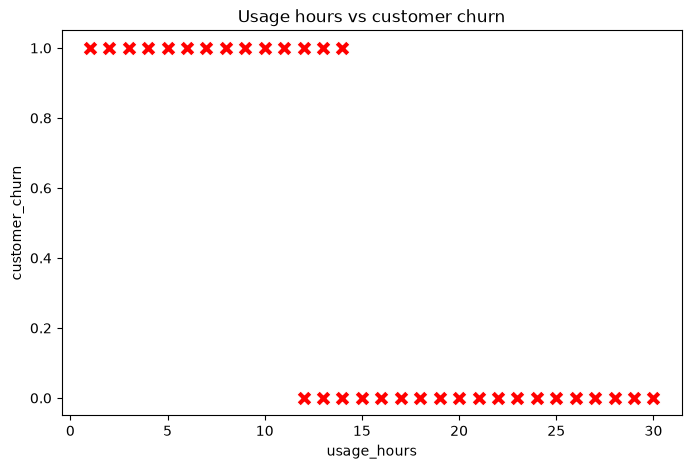

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='usage_hours', y='customer_churn', marker='X', s=120, color='red')
plt.title("Usage hours vs customer churn")
plt.show()

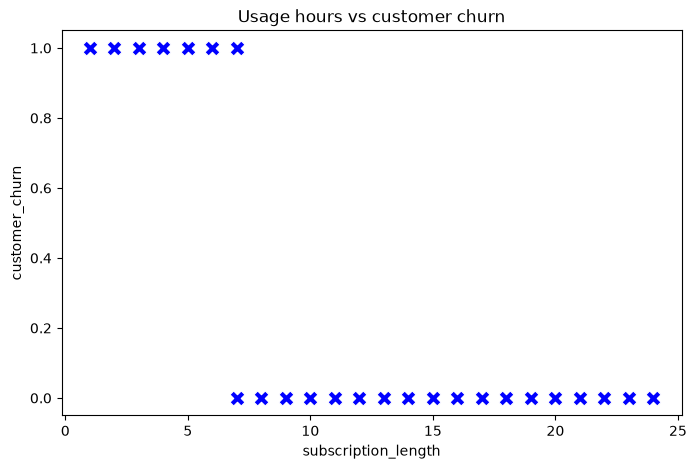

In [6]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='subscription_length', y='customer_churn', marker='X', s=120, color='blue')
plt.title("Usage hours vs customer churn")
plt.show()

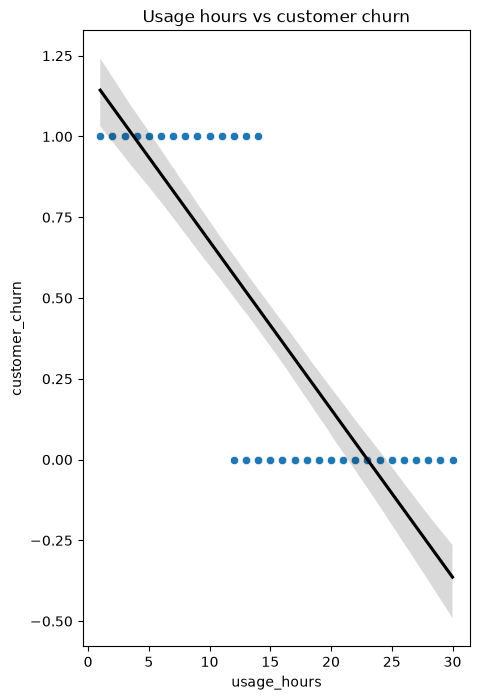

In [9]:
plt.figure(figsize=(5,8))
sns.scatterplot(data=df, x='usage_hours', y='customer_churn', markers='X')
sns.regplot(data=df,  x='usage_hours', y='customer_churn', scatter=False, color='black')
plt.title("Usage hours vs customer churn")
plt.show()

In [ ]:
X = df[['usage_hours', 'subscription_length']]
y = df['customer_churn']

# we will use both features: usage hours and subscription length to predict customer churn
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

Training set: 57 samples
Testing set: 19 samples


In [11]:
# create and train logistic reg model

# the 'lbfgs' solver is an optimization algo suitable for samll to medium sized datasets
model = LogisticRegression(solver='lbfgs')

# train the model
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [12]:
#examine model coef
print(f"Intercept:", model.intercept_)

Intercept: [17.00597206]


In [13]:
#evaluate the model

y_pred = model.predict(X_test)
print("Predictions:", y_pred)

Predictions: [1 0 1 1 0 0 0 0 0 1 0 0 1 1 0 0 1 1 0]


In [14]:
#Calculate accuracy
accuracy = model.score(X_test, y_test)
print(f"Model accuracy: {accuracy:.2f} ({accuracy*100: .1f}%)")

Model accuracy: 1.00 ( 100.0%)


In [16]:
#show the prediction probabilities
# each row gives [prob of not churning, prob of churning]

proba = model.predict_proba(X_test)
proba_df = pd.DataFrame(proba, columns=['Prob(Not churn)', 'Prob(churn)']).round(2)
proba_df['Actual'] = y_test.values
proba_df['Predicted'] = y_pred
proba_df

,Prob(Not churn),Prob(churn),Actual,Predicted
0,0.00,1.00,1,1
1,0.99,0.01,0,0
2,0.00,1.00,1,1
3,0.00,1.00,1,1
4,1.00,0.00,0,0
5,1.00,0.00,0,0
6,1.00,0.00,0,0
7,1.00,0.00,0,0
8,1.00,0.00,0,0
9,0.29,0.71,1,1


In [18]:
# confusion matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm

array([[11,  0],
       [ 0,  8]])

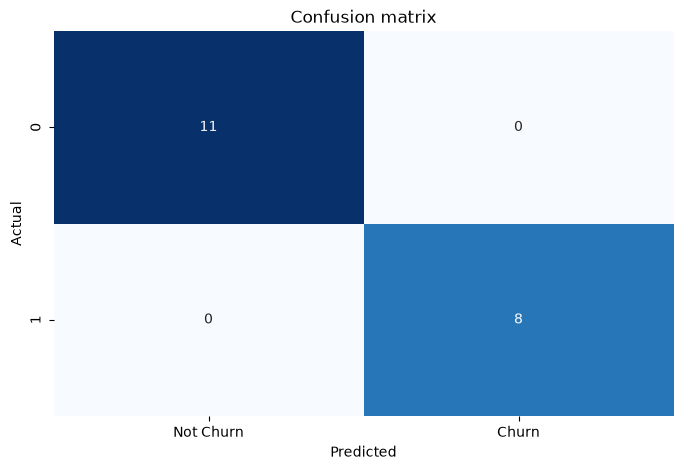

In [20]:
#visualize confusion matrix
plt.figure(figsize=(8,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Churn', 'Churn'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix")
plt.show()

In [21]:
from sklearn.metrics import classification_report
 #print classification report

print("Classification report:")
print(classification_report(y_test, y_pred))

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00         8

    accuracy                           1.00        19
   macro avg       1.00      1.00      1.00        19
weighted avg       1.00      1.00      1.00        19



Logistic Regression - Example and Practice Exercise

Exercise : Simple Logistic Regression

Problem Statement

* You are provided with a dataset (`student_exam.csv`) containing student features such as study hours and previous exam scores.

* The goal is to build a logistic regression model to predict whether a student will pass or fail an exam.

* You need to explore and visualize the data, then prepare it for modeling.

* The split the dataset into training and testing sets.

* Train a logistic regression model and evaluate it on test data.

* Visualize the decision boundary to interpret the model behavior.

In [23]:
df2 = pd.read_csv("student_exam.csv")
df2.head()

,study_hours,previous_score,passed_exam
0,2.0,45,0
1,3.0,50,0
2,2.5,55,0
3,4.0,60,0
4,5.0,62,0


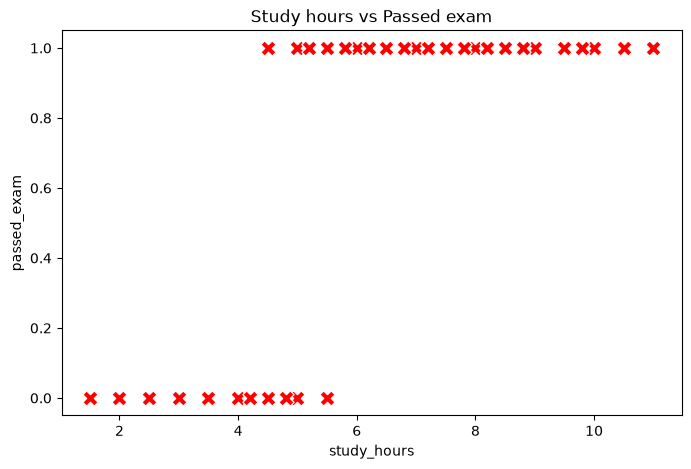

In [25]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df2, x='study_hours', y='passed_exam', marker='X', s=120, color='red')
plt.title("Study hours vs Passed exam")
plt.show()

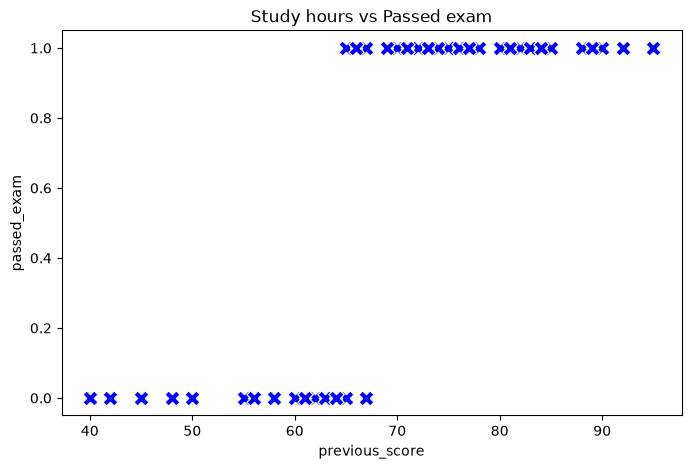

In [29]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df2, x='previous_score', y='passed_exam', marker='X', s=120, color='blue')
plt.title("Study hours vs Passed exam")
plt.show()

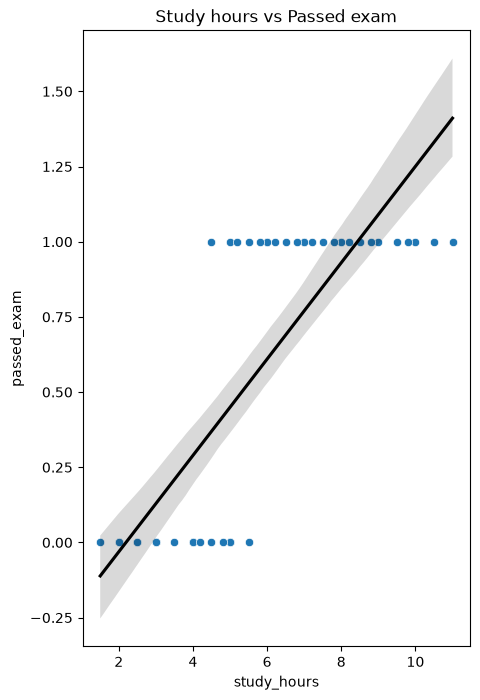

In [30]:
plt.figure(figsize=(5,8))
sns.scatterplot(data=df2, x='study_hours', y='passed_exam', markers='X')
sns.regplot(data=df2,  x='study_hours', y='passed_exam', scatter=False, color='black')
plt.title("Study hours vs Passed exam")
plt.show()

In [32]:
X = df2[['study_hours', 'previous_score']]
y = df2['passed_exam']

# we will use both features: study hours and previous_score to predict customer churn
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

Training set: 36 samples
Testing set: 13 samples


In [33]:
# the 'lbfgs' solver is an optimization algo suitable for samll to medium sized datasets
model = LogisticRegression(solver='lbfgs')

# train the model
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [34]:
#evaluate the model

y_pred = model.predict(X_test)
print("Predictions:", y_pred)

Predictions: [1 1 1 1 0 0 0 0 1 1 1 0 1]


In [35]:
#Calculate accuracy
accuracy = model.score(X_test, y_test)
print(f"Model accuracy: {accuracy:.2f} ({accuracy*100: .1f}%)")

Model accuracy: 1.00 ( 100.0%)


In [36]:
proba = model.predict_proba(X_test)
proba_df = pd.DataFrame(proba, columns=['Prob(NOt passed)', 'Prob(Passed)']).round(2)
proba_df['Actual'] = y_test.values
proba_df['Predicted'] = y_pred
proba_df

,Prob(NOt passed),Prob(Passed),Actual,Predicted
0,0.00,1.00,1,1
1,0.01,0.99,1,1
2,0.00,1.00,1,1
3,0.09,0.91,1,1
4,0.90,0.10,0,0
5,1.00,0.00,0,0
6,1.00,0.00,0,0
7,1.00,0.00,0,0
8,0.00,1.00,1,1
9,0.01,0.99,1,1


In [37]:
# confusion matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm

array([[5, 0],
       [0, 8]])

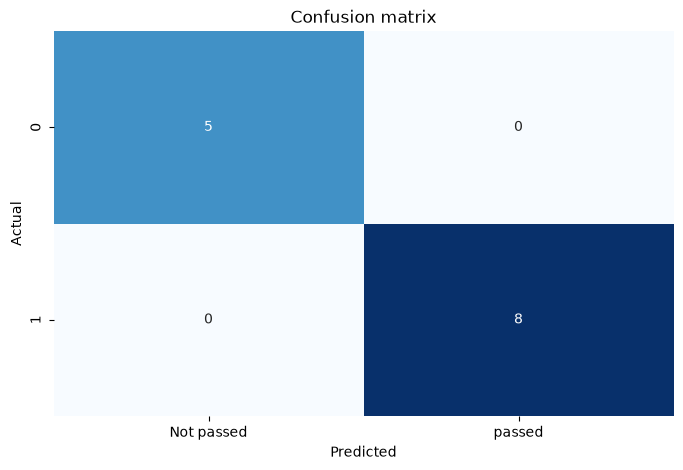

In [39]:
#visualize confusion matrix
plt.figure(figsize=(8,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not passed', 'passed'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix")
plt.show()

In [40]:
from sklearn.metrics import classification_report
 #print classification report

print("Classification report:")
print(classification_report(y_test, y_pred))

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         8

    accuracy                           1.00        13
   macro avg       1.00      1.00      1.00        13
weighted avg       1.00      1.00      1.00        13

